In [1]:
import numpy as np
import gymnasium as gym
from typing import Dict, Tuple, Optional
from enum import Enum
from gymnasium.error import DependencyNotInstalled
import pygame

In [97]:
class StateIds(Enum):
    BAY = 0
    ROW = 1
    TIER = 2
    IS_OCCUPIED = 3


class StowageEnv(gym.Env):
    """
    Args:
        container_type (str): Type of container to place in the yard. Can be one of ["one", "two", "mixed"].
            - "one": Place only the 20-feet containers in the yard.
            - "two": Place only the 40-feet containers in the yard.
            - "mixed": Place both 20-feet and 40-feet containers in the yard.
    """

    metadata = {
        "render_modes": ["rgb_array"],
    }

    def __init__(self, config: Dict = None, render_mode: Optional[str] = None):
        # Render part
        self.render_mode = render_mode
        self.screen_width = 600
        self.screen_height = 400
        self.screen = None
        self.isopen = True

        if config is None:
            config = {}

        self.vessel_shape = config.get("vessel_shape", (1, 2, 2))
        self.yard_shape = config.get("yard_shape", (2, 2, 2))
        self.num_containers = config.get("num_containers", 4)
        self.container_type = config.get("container_type", "one")

        # Calculate total physical slots
        self.total_vessel_slots = self.vessel_shape[0] * self.vessel_shape[1] * self.vessel_shape[2]
        self.total_yard_slots = self.yard_shape[0] * self.yard_shape[1] * self.yard_shape[2]

        self.num_containers = min(self.num_containers, self.total_yard_slots)

        # Calculate total coordinates
        self.num_vessel_bay = (
            self.vessel_shape[0] // 2 + self.vessel_shape[0]
        )  # number of bay coords. e.g., need 6 coords to encode 4 bays
        self.num_yard_bay = self.yard_shape[0] // 2 + self.yard_shape[0]
        self.total_vessel_coords = self.num_vessel_bay * self.vessel_shape[1] * self.vessel_shape[2]
        self.total_yard_coords = self.num_yard_bay * self.yard_shape[1] * self.yard_shape[2]
        self.obs_coords = self.total_vessel_coords + self.total_yard_coords + 1  # +1 for current target

        # Sequencer
        self.current_vessel_slot = None
        self.vessel_slots_filled = 0

        # Observation and action spaces
        self.observation_space = gym.spaces.Box(
            low=0,
            high=max(
                max(self.num_vessel_bay, self.num_yard_bay),  # bay upper limit
                max(self.vessel_shape[1], self.yard_shape[1]),  # row upper limit
                max(self.vessel_shape[2], self.yard_shape[2]),  # tier upper limit
                1,  # occupied upper limit
            ),
            shape=(self.obs_coords, 4),
            dtype=np.int32,
        )
        self.action_space = gym.spaces.Discrete(self.yard_shape[0] * self.yard_shape[1] * self.yard_shape[2])
        # Each slot stores 4 values: bay, row, tier, occupied(0/1)

    def step(self, action):
        terminated = False
        truncated = False
        info = {}

        # Check if the action is valid (container exists and is accessible)
        valid_actions = self._get_valid_yard_actions().tolist()

        if action not in valid_actions:
            # Invalid action - return large negative reward
            reward = -100.0
            observation = self._create_observation()
            info["yard_mask"] = valid_actions
            return observation, reward, terminated, truncated, info

        original_bay = self.yard_state[action, StateIds.BAY.value]
        original_row = self.yard_state[action, StateIds.ROW.value]
        original_tier = self.yard_state[action, StateIds.TIER.value]
        # Identify the container stacking on top of the action container
        same_bay_row_mask = (
            (self.yard_state[:, StateIds.BAY.value] == original_bay)
            & (self.yard_state[:, StateIds.ROW.value] == original_row)
            & (self.yard_state[:, StateIds.TIER.value] > original_tier)
            & (self.yard_state[:, StateIds.IS_OCCUPIED.value] == 1)
        )

        upper_slots = np.where(same_bay_row_mask)[
            0
        ]  # get the indices of the containers that are above the action container in ascending order of tier
        sorted_upper_slots = []  # sort the upper slots in descending order of tier
        if len(upper_slots) > 0:
            sorted_upper_slots = sorted(
                upper_slots, key=lambda x: self.yard_state[x, StateIds.TIER.value], reverse=True
            )

            self.yard_state[sorted_upper_slots[0], StateIds.IS_OCCUPIED.value] = (
                0  # remove the top container in the same stack
            )

            for i in range(1, len(sorted_upper_slots)):  # From top to bottom, move the containers one slot down
                current_slot = sorted_upper_slots[i]
                self.yard_state[current_slot, StateIds.TIER.value] -= 1

        else:
            self.yard_state[action, StateIds.IS_OCCUPIED.value] = 0
        self.vessel_state[self.current_vessel_slot, StateIds.IS_OCCUPIED.value] = 1

        self.vessel_slots_filled += 1
        self.current_vessel_slot = self._get_next_vessel_slot()

        shifters = len(sorted_upper_slots)
        reward = -shifters

        terminated = self.current_vessel_slot is None
        valid_actions = self._get_valid_yard_actions()

        observation = self._create_observation()
        info.update({"yard_mask": valid_actions, "shifters": shifters, "vessel_slots_filled": self.vessel_slots_filled})

        return observation, reward, terminated, truncated, info

    def reset(self):
        yard_bays = self._generate_bay_coords(self.yard_shape[0])
        _, R, T = self.yard_shape
        self.yard_state = np.zeros((self.total_yard_coords, 4), dtype=int)
        # Generate coords in bay-row-tier order
        self.yard_state[:, StateIds.BAY.value] = np.repeat(yard_bays, R * T)
        self.yard_state[:, StateIds.ROW.value] = np.tile(np.arange(1, R + 1).repeat(T), len(yard_bays))
        self.yard_state[:, StateIds.TIER.value] = np.tile(np.arange(1, T + 1), len(yard_bays) * R)

        physical_vessel_bays = self.vessel_shape[0]
        vessel_bays = self._generate_bay_coords(physical_vessel_bays)
        _, Rv, Tv = self.vessel_shape
        self.vessel_state = np.zeros((self.total_vessel_coords, 4), dtype=int)

        self.vessel_state[:, StateIds.BAY.value] = np.repeat(vessel_bays, Rv * Tv)
        self.vessel_state[:, StateIds.ROW.value] = np.tile(np.arange(1, Rv + 1).repeat(Tv), len(vessel_bays))
        self.vessel_state[:, StateIds.TIER.value] = np.tile(np.arange(1, Tv + 1), len(vessel_bays) * Rv)

        self.vessel_slots_filled = 0

        self._initialize_containers()

        # Get the next vessel slot to fill
        self.current_vessel_slot = self._get_next_vessel_slot()

        # Create observation
        observation = self._create_observation()
        info = {}

        return observation, info

    def _generate_bay_coords(self, physical_bays: int) -> list:
        """Generate bay coordinates based on the number of physical bays."""
        bay_groups = []
        group_start = 1

        for _ in range(physical_bays // 2):
            bay_groups.extend([group_start, group_start + 1, group_start + 2])
            group_start += 4

        if physical_bays % 2 == 1:
            bay_groups.append(group_start)

        return bay_groups

    def _get_next_vessel_slot(self) -> Optional[Tuple[int, int, int]]:
        if self.container_type == "one":
            valid_slots = np.where(
                (self.vessel_state[:, StateIds.IS_OCCUPIED.value] == 0)
                & (self.vessel_state[:, StateIds.BAY.value] % 2 == 1)
            )[0]
            if len(valid_slots) == 0:
                return None
            return valid_slots[0]

    def _create_observation(self):
        state = np.concatenate((self.vessel_state, self.yard_state), axis=0)
        if self.current_vessel_slot is not None:
            state = np.concatenate((state, self.vessel_state[self.current_vessel_slot].reshape(1, -1)), axis=0)
        else:
            state = np.concatenate((state, np.zeros((1, 4), dtype=int)), axis=0)
        return state

    def _get_valid_yard_actions(self) -> np.ndarray:
        occupied_mask = self.yard_state[:, StateIds.IS_OCCUPIED.value] == 1
        if self.container_type == "one":
            bay_mask = self.yard_state[:, StateIds.BAY.value] % 2 == 1
            valid_actions = np.where(occupied_mask & bay_mask)[0]
        return valid_actions

    def render(self):
        """Render the environment as an RGB array"""
        if self.render_mode != "rgb_array":
            return None

        try:
            import os

            os.environ["SDL_VIDEODRIVER"] = "dummy"
            import pygame
        except ImportError:
            raise ImportError("pygame is not installed")

        # Initialize pygame and surface
        if not pygame.get_init():
            pygame.init()
        if self.screen is None:
            self.screen = pygame.Surface((self.screen_width, self.screen_height))

        # Clear screen
        self.screen.fill((255, 255, 255))

        # Layout parameters
        padding, title_height, section_gap = 10, 20, 30
        vessel_height = (self.screen_height - 3 * padding - 2 * title_height) * 0.4
        yard_height = (self.screen_height - 3 * padding - 2 * title_height) * 0.6

        # Draw section titles
        font = pygame.font.Font(None, 24)
        self.screen.blit(font.render("Vessel", True, (0, 0, 0)), (padding, padding))
        self.screen.blit(font.render("Yard", True, (0, 0, 0)), (padding, padding + vessel_height + section_gap))

        # Draw vessel and yard
        self._draw_grid(
            self.vessel_state,
            padding + title_height,
            vessel_height,
            self.vessel_shape[0],
            self.vessel_shape[1],
            self.vessel_shape[2],
            True,
        )

        self._draw_grid(
            self.yard_state,
            padding + title_height + vessel_height + section_gap,
            yard_height,
            self.yard_shape[0],
            self.yard_shape[1],
            self.yard_shape[2],
            False,
        )

        # Return RGB array
        return np.transpose(np.array(pygame.surfarray.pixels3d(self.screen)), axes=(1, 0, 2))

    def _draw_grid(self, state, top, height, bays, rows, tiers, is_vessel):
        """Draw a grid section (vessel or yard) with fixed cell size"""
        import pygame

        # Fixed cell size and layout constants
        cell_width, cell_height, padding, label_margin = 35, 35, 30, 15
        left_margin = max(padding, (self.screen_width - bays * rows * cell_width) / 2)
        small_font = pygame.font.Font(None, 20)
        tiny_font = pygame.font.Font(None, 18)

        # Draw tier labels and bay labels
        for t in range(1, tiers + 1):
            y = top + (tiers - t) * cell_height + cell_height / 2
            self.screen.blit(
                small_font.render(f"{t}", True, (0, 0, 0)),
                (left_margin - label_margin, y - small_font.render(f"{t}", True, (0, 0, 0)).get_height() / 2),
            )

        for b in range(bays):
            bay_num = b * 2 + 1
            bay_x = left_margin + b * rows * cell_width + (rows * cell_width) / 2
            bay_label = small_font.render(f"Bay {bay_num}", True, (0, 0, 0))
            self.screen.blit(bay_label, bay_label.get_rect(center=(bay_x, top - 10)))

        # Map state to grid cells
        occupied_cells = {}
        for i in range(len(state)):
            bay, row, tier = [int(state[i, j]) for j in [StateIds.BAY.value, StateIds.ROW.value, StateIds.TIER.value]]
            is_occupied = state[i, StateIds.IS_OCCUPIED.value] == 1
            is_target = is_vessel and self.current_vessel_slot == i

            if is_occupied or is_target:
                if bay % 2 == 1:
                    occupied_cells[(bay, row, tier)] = {"filled": is_occupied, "target": is_target, "idx": i}
                else:
                    for adj_bay in [bay - 1, bay + 1]:
                        if 1 <= adj_bay <= bays * 2:
                            occupied_cells[(adj_bay, row, tier)] = {
                                "filled": is_occupied,
                                "target": is_target,
                                "idx": i,
                            }

        # Draw all cells and row labels
        for b in range(bays):
            bay_num = b * 2 + 1
            for r in range(1, rows + 1):
                # Draw row label at bottom
                x_label = left_margin + b * rows * cell_width + (r - 1) * cell_width + cell_width / 2
                self.screen.blit(
                    small_font.render(f"{r}", True, (0, 0, 0)),
                    small_font.render(f"{r}", True, (0, 0, 0)).get_rect(
                        center=(x_label, top + tiers * cell_height + label_margin / 2)
                    ),
                )

                for t in range(1, tiers + 1):
                    x = left_margin + b * rows * cell_width + (r - 1) * cell_width
                    y = top + (tiers - t) * cell_height

                    cell = occupied_cells.get((bay_num, r, t), {"filled": False, "target": False, "idx": None})
                    color = (0, 102, 204) if cell["filled"] else (255, 255, 255)
                    rect = pygame.Rect(x, y, cell_width, cell_height)

                    # Draw cell
                    pygame.draw.rect(self.screen, color, rect)
                    pygame.draw.rect(
                        self.screen, (255, 0, 0) if cell["target"] else (0, 0, 0), rect, 3 if cell["target"] else 1
                    )

                    if cell["filled"] and cell["idx"] is not None:
                        label = tiny_font.render(f"{cell['idx']}", True, (255, 255, 255))
                        self.screen.blit(label, label.get_rect(center=(x + cell_width / 2, y + cell_height / 2)))

    def _get_bay_groups(self, type="yard") -> dict:
        """generate bay groups based on the yard shape
        Returns:
            dict: dictionary containing bay groups, e.g. {1: [1, 2, 3], 2: [5, 6, 7]}
        """
        state = self.yard_state if type == "yard" else self.vessel_state
        bays = sorted(np.unique(state[:, StateIds.BAY.value]))

        groups, current_group, group_id = {}, [], 1

        for bay in bays:
            if current_group and bay - current_group[-1] > 1:
                groups[group_id] = current_group
                current_group, group_id = [], group_id + 1
            current_group.append(bay)

        if current_group:
            groups[group_id] = current_group

        return groups

    def _initialize_containers(self):
        if self.container_type == "one":
            odd_bay_mask = self.yard_state[:, StateIds.BAY.value] % 2 != 0
            available_slots = np.where(odd_bay_mask)[0]
            num_to_set = min(self.num_containers, len(available_slots))
            if num_to_set > 0:
                self.yard_state[available_slots[:num_to_set], StateIds.IS_OCCUPIED.value] = 1


In [98]:
config_dict = {
    "vessel_shape": (1,2,2),
    "yard_shape": (3,1,2),
    "num_containers": 6
}
env = StowageEnv(config=config_dict, render_mode="rgb_array")
print("Vessel bay numbers:", env.num_vessel_bay)
print("Yard bay numbers:", env.num_yard_bay)

observation, info = env.reset()
print('Vessel shape:', env.vessel_shape)
print('Yard shape:', env.yard_shape)
print('Number of containers:', env.num_containers)
print('Total vessel slots:', env.total_vessel_slots)
print('Total yard slots:', env.total_yard_slots)
print('Observation space:', env.observation_space)
print('Action space:', env.action_space)
print('Vessel state:', env.vessel_state)
print('Yard state:', env.yard_state)
print('Current vessel slot:', env.current_vessel_slot)
print('Observation:', observation)
print(env._get_valid_yard_actions())

Vessel bay numbers: 1
Yard bay numbers: 4
Vessel shape: (1, 2, 2)
Yard shape: (3, 1, 2)
Number of containers: 6
Total vessel slots: 4
Total yard slots: 6
Observation space: Box(0, 4, (13, 4), int32)
Action space: Discrete(6)
Vessel state: [[1 1 1 0]
 [1 1 2 0]
 [1 2 1 0]
 [1 2 2 0]]
Yard state: [[1 1 1 1]
 [1 1 2 1]
 [2 1 1 0]
 [2 1 2 0]
 [3 1 1 1]
 [3 1 2 1]
 [5 1 1 1]
 [5 1 2 1]]
Current vessel slot: 0
Observation: [[1 1 1 0]
 [1 1 2 0]
 [1 2 1 0]
 [1 2 2 0]
 [1 1 1 1]
 [1 1 2 1]
 [2 1 1 0]
 [2 1 2 0]
 [3 1 1 1]
 [3 1 2 1]
 [5 1 1 1]
 [5 1 2 1]
 [1 1 1 0]]
[0 1 4 5 6 7]


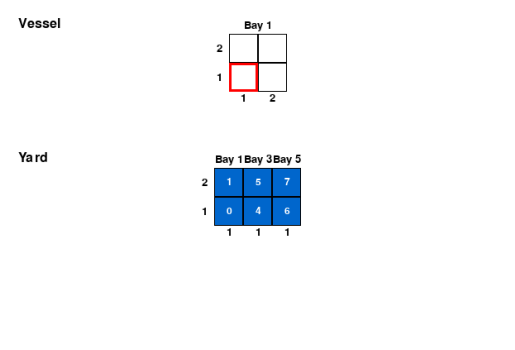

In [99]:
import matplotlib.pyplot as plt

# Get the RGB array
rgb_array = env.render()

# Display the image
plt.imshow(rgb_array)
plt.axis('off')  # Hide axes
plt.show()

Reward: -1
Info: {'yard_mask': array([0, 4, 5, 6, 7]), 'shifters': 1, 'vessel_slots_filled': 1}


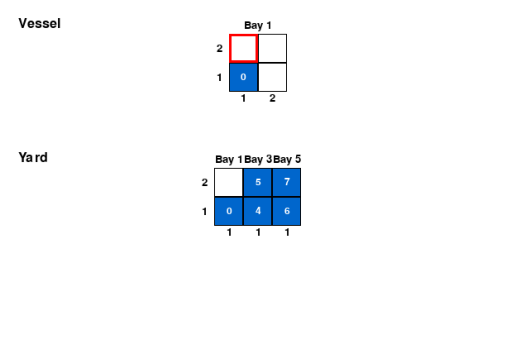

In [100]:
observation, reward, terminated, truncated, info = env.step(0)
print('Reward:', reward)
print('Info:', info)
rgb_array = env.render()
plt.imshow(rgb_array)
plt.axis('off')  # Hide axes
plt.show()

Reward: 0
Info: {'yard_mask': array([0, 4, 6, 7]), 'shifters': 0, 'vessel_slots_filled': 2}


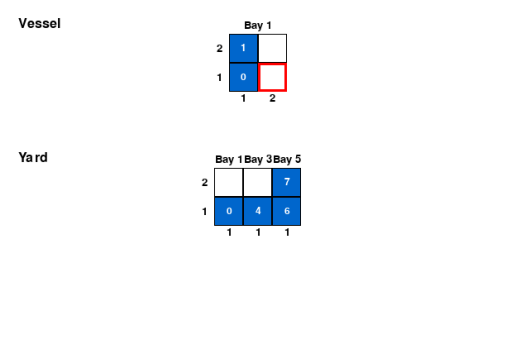

In [101]:
observation, reward, terminated, truncated, info = env.step(5)
print('Reward:', reward)
print('Info:', info)
rgb_array = env.render()
plt.imshow(rgb_array)
plt.axis('off')  # Hide axes
plt.show()

Reward: -1
Info: {'yard_mask': array([0, 4, 6]), 'shifters': 1, 'vessel_slots_filled': 3}


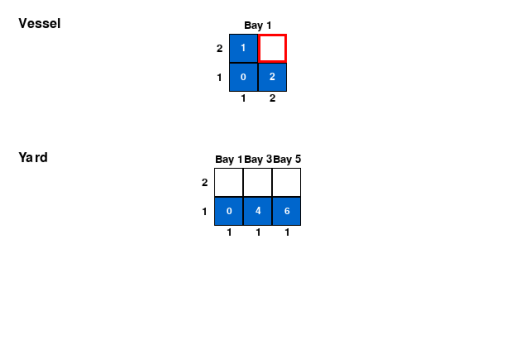

In [103]:
observation, reward, terminated, truncated, info = env.step(6)
print('Reward:', reward)
print('Info:', info)
rgb_array = env.render()
plt.imshow(rgb_array)
plt.axis('off')  # Hide axes
plt.show()

Reward: 0
Info: {'yard_mask': array([4, 6]), 'shifters': 0, 'vessel_slots_filled': 4}


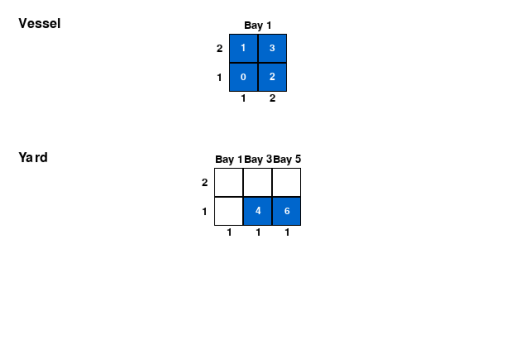

In [104]:
observation, reward, terminated, truncated, info = env.step(0)
print('Reward:', reward)
print('Info:', info)
rgb_array = env.render()
plt.imshow(rgb_array)
plt.axis('off')  # Hide axes
plt.show()